# Analyse Exploratoire des Données (EDA) — Prédiction du churn

**Projet** : Système Intelligent Multi-Modèles pour la Rétention Client
**Dataset** : `data/customer_churn_business_dataset.csv` — 10 000 clients × 32 variables
**Cible** : `churn` (0 = reste, 1 = résilie)

Objectif de cette EDA : comprendre la structure des données, le déséquilibre de la cible,
identifier les variables porteuses de signal et les pièges (manquants, multicolinéarité)
avant toute modélisation.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Accès au module de config du projet
sys.path.insert(0, str(Path.cwd().parent))
from src import config

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
FIG = config.FIGURES_DIR
print("Figures sauvegardées dans :", FIG.relative_to(config.ROOT))

Figures sauvegardées dans : reports/figures


## 1. Chargement et aperçu général

In [2]:
df = config.load_raw()
print("Dimensions :", df.shape)
df.head()

Dimensions : (10000, 32)


,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_method,payment_failures,discount_applied,price_increase_last_3m,support_tickets,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,7,11.762372,5,0.06,7,30,660,PayPal,1,Yes,No,4,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,5,26.846390,1,-0.28,2,30,270,Card,1,No,Yes,1,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,5,23.380065,6,0.13,23,20,1160,Card,2,No,No,1,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,7,24.243136,2,-0.17,24,30,570,Bank Transfer,0,Yes,No,3,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,6,18.872323,2,-0.16,2,50,2600,PayPal,0,No,No,0,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             10000 non-null  object 
 1   gender                  10000 non-null  object 
 2   age                     10000 non-null  int64  
 3   country                 10000 non-null  object 
 4   city                    10000 non-null  object 
 5   customer_segment        10000 non-null  object 
 6   tenure_months           10000 non-null  int64  
 7   signup_channel          10000 non-null  object 
 8   contract_type           10000 non-null  object 
 9   monthly_logins          10000 non-null  int64  
 10  weekly_active_days      10000 non-null  int64  
 11  avg_session_time        10000 non-null  float64
 12  features_used           10000 non-null  int64  
 13  usage_growth_rate       10000 non-null  float64
 14  last_login_days_ago     10000 non-null 

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,10000.0,45.906100,16.420416,18.00,32.000000,46.000000,60.000000,74.000000
tenure_months,10000.0,30.155700,17.099517,1.00,16.000000,30.000000,45.000000,59.000000
monthly_logins,10000.0,19.672000,9.838003,0.00,13.000000,20.000000,26.000000,54.000000
weekly_active_days,10000.0,3.479400,2.302283,0.00,1.000000,3.000000,5.000000,7.000000
avg_session_time,10000.0,15.187890,6.830774,1.00,10.391645,15.161659,19.882034,41.996411
features_used,10000.0,4.990800,2.211607,1.00,3.000000,5.000000,6.000000,15.000000
usage_growth_rate,10000.0,0.019423,0.149567,-0.58,-0.080000,0.020000,0.120000,0.540000
last_login_days_ago,10000.0,9.505200,9.799417,0.00,2.000000,6.000000,13.000000,80.000000
monthly_fee,10000.0,34.930000,23.785115,10.00,20.000000,30.000000,50.000000,100.000000
total_revenue,10000.0,1057.018000,1020.148233,10.00,340.000000,720.000000,1440.000000,5900.000000


## 2. Variable cible : un fort déséquilibre

En churn, la classe positive est typiquement minoritaire. C'est déterminant pour le choix
des métriques : l'accuracy seule serait trompeuse (un modèle prédisant toujours « reste »
atteindrait déjà ~90 %). On privilégiera **Recall, F1 et PR-AUC**.

Taux de churn global : 10.2%
{0: 8979, 1: 1021}


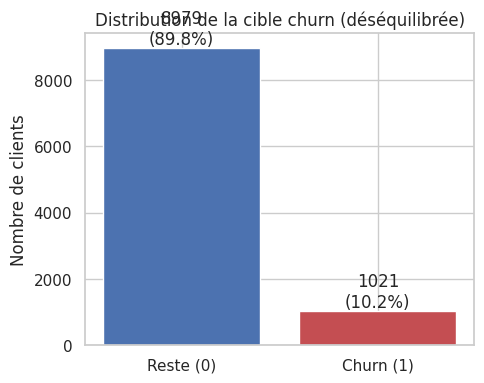

In [5]:
rate = df[config.TARGET].mean()
counts = df[config.TARGET].value_counts().sort_index()
print(f"Taux de churn global : {rate:.1%}")
print(counts.to_dict())

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Reste (0)", "Churn (1)"], counts.values, color=["#4C72B0", "#C44E52"])
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v}\n({v/len(df):.1%})", ha="center", va="bottom")
ax.set_title("Distribution de la cible churn (déséquilibrée)")
ax.set_ylabel("Nombre de clients")
fig.tight_layout(); fig.savefig(FIG/"01_churn_balance.png", dpi=120); plt.show()

## 3. Valeurs manquantes

Seule `complaint_type` contient des manquants (~20 %). Interprétation métier : absence de
plainte. On les imputera par la modalité `"None"` (et non une suppression de lignes).

In [6]:
miss = df.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
print("Colonnes avec manquants :")
print(miss if len(miss) else "Aucune")
print("\nModalités de complaint_type :", df["complaint_type"].value_counts(dropna=False).to_dict())

Colonnes avec manquants :
complaint_type    2045
dtype: int64

Modalités de complaint_type : {'Technical': 3498, 'Billing': 2427, nan: 2045, 'Service': 2030}


In [ ]:
# Visualisation des colonnes avec valeurs manquantes
missing_df = df.isna().sum().rename("missing_values").to_frame()
missing_df["missing_percent"] = missing_df["missing_values"] / len(df) * 100
missing_df_filtered = (
    missing_df[missing_df["missing_values"] > 0]
    .sort_values("missing_percent", ascending=False)
    .reset_index()
    .rename(columns={"index": "variable"})
)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=missing_df_filtered,
    x="variable",
    y="missing_percent"
)
plt.title("Pourcentage de valeurs manquantes par variable")
plt.xlabel("Variable")
plt.ylabel("Valeurs manquantes (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 4. Distributions des variables numériques

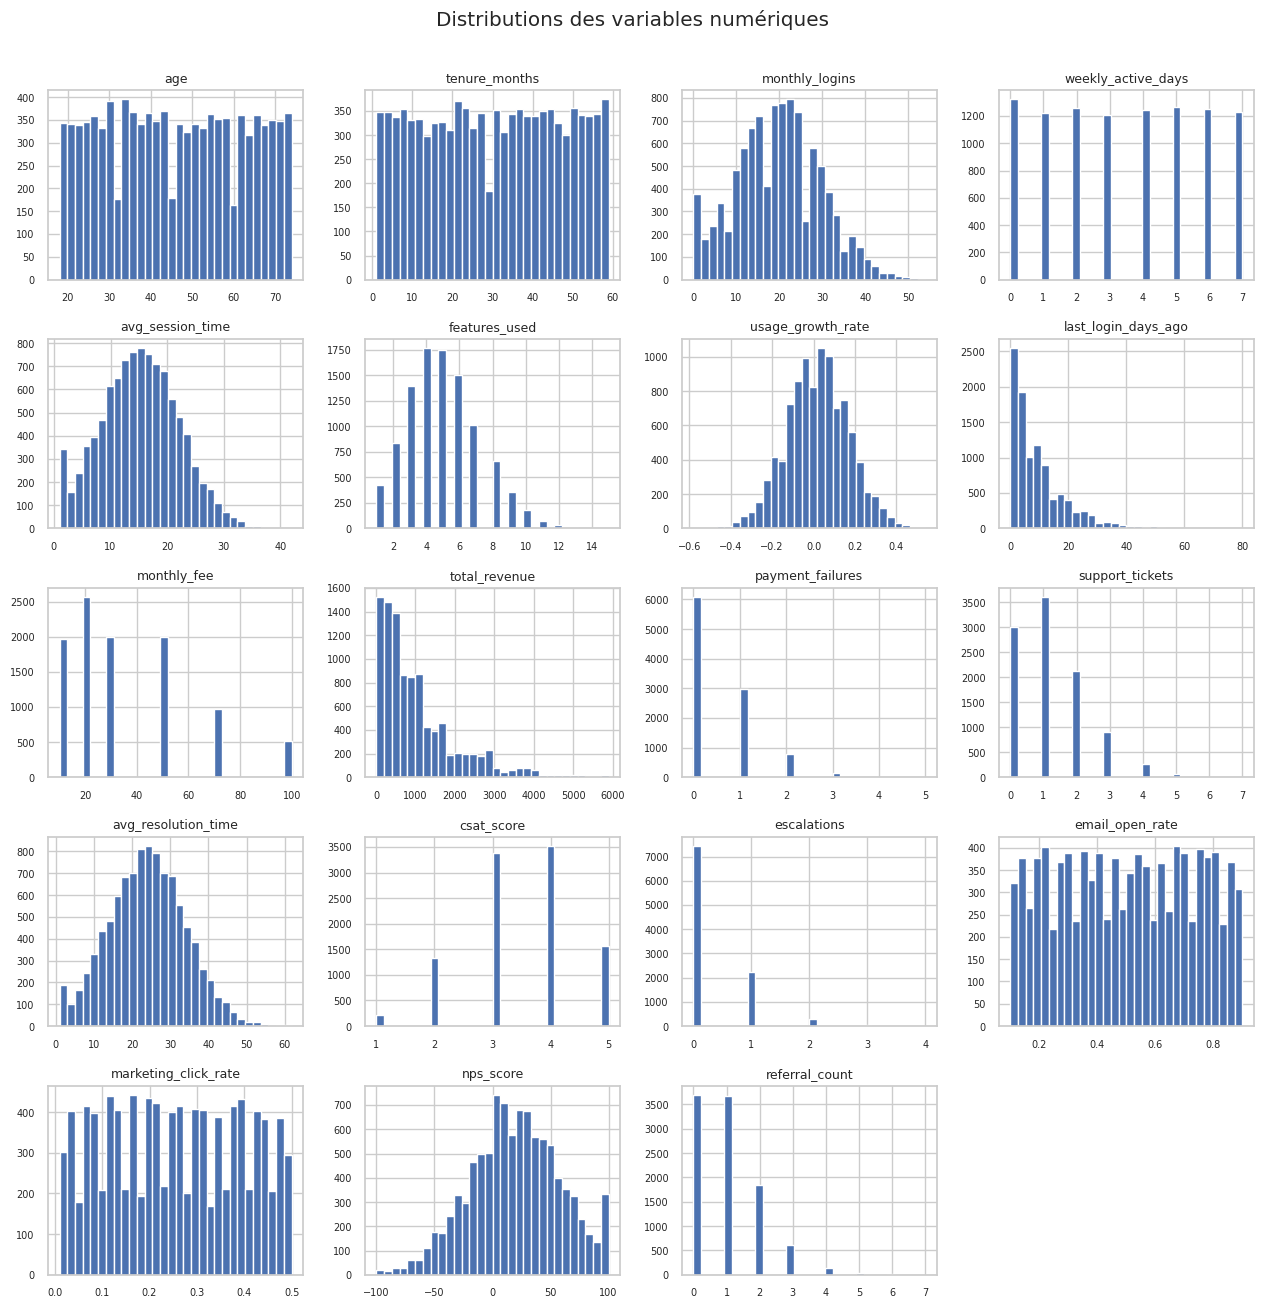

In [7]:
num = config.NUMERIC_FEATURES
ncol = 4; nrow = int(np.ceil(len(num)/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(ncol*3.2, nrow*2.6))
for ax, col in zip(axes.ravel(), num):
    ax.hist(df[col].dropna(), bins=30, color="#4C72B0")
    ax.set_title(col, fontsize=9); ax.tick_params(labelsize=7)
for ax in axes.ravel()[len(num):]:
    ax.axis("off")
fig.suptitle("Distributions des variables numériques", y=1.005)
fig.tight_layout(); fig.savefig(FIG/"02_numeric_distributions.png", dpi=120); plt.show()

## 5. Corrélations

### 5.1 Matrice de corrélation (Pearson)

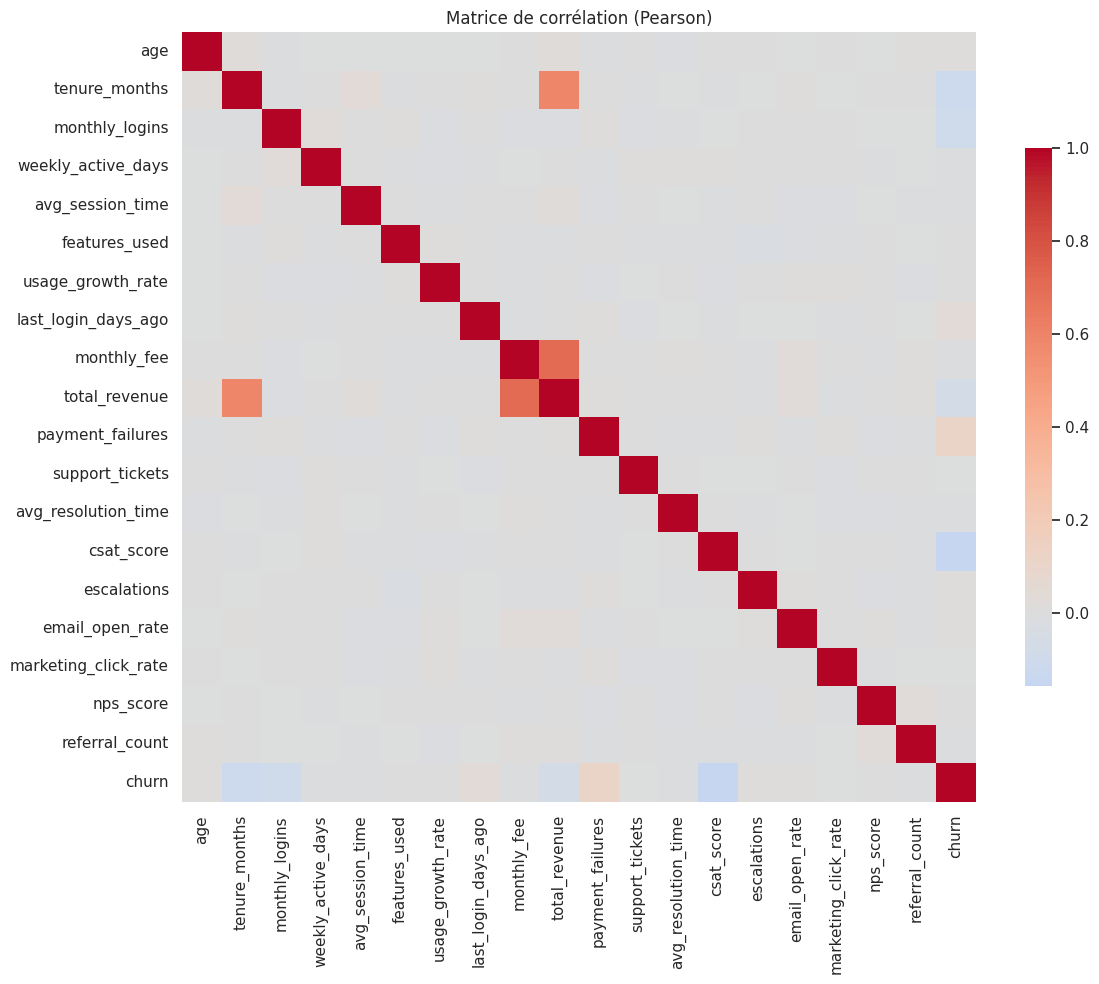

In [8]:
corr = df[num + [config.TARGET]].corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax, cbar_kws={"shrink":0.7})
ax.set_title("Matrice de corrélation (Pearson)")
fig.tight_layout(); fig.savefig(FIG/"03_correlation_matrix.png", dpi=120); plt.show()

### 5.2 Corrélation linéaire avec la cible

⚠️ Les corrélations de Pearson avec `churn` sont **faibles** (|r| < 0.16). Cela ne signifie
PAS qu'il n'y a pas de signal : Pearson ne mesure que les relations **linéaires**. On verra
en 6 que le vrai signal est **non-linéaire** (effets de seuil).

,corr_avec_churn
csat_score,-0.158
tenure_months,-0.117
monthly_logins,-0.098
total_revenue,-0.070
avg_resolution_time,-0.009
weekly_active_days,-0.009
referral_count,-0.007
monthly_fee,-0.005
avg_session_time,-0.005
marketing_click_rate,-0.002


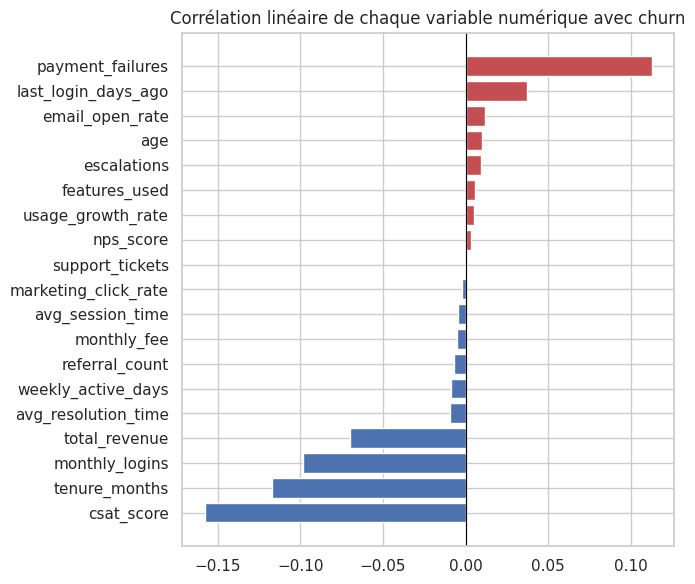

In [9]:
target_corr = corr[config.TARGET].drop(config.TARGET).sort_values()
display(target_corr.to_frame("corr_avec_churn").round(3))

fig, ax = plt.subplots(figsize=(7, 6))
colors = ["#C44E52" if v > 0 else "#4C72B0" for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Corrélation linéaire de chaque variable numérique avec churn")
fig.tight_layout(); fig.savefig(FIG/"04_corr_with_target.png", dpi=120); plt.show()

## 6. Le vrai signal : des drivers à effet de seuil (non-linéaires)

C'est l'insight central de l'EDA. En regroupant par tranches, on voit des relations fortes
que Pearson masquait :

- **Ancienneté ≤ 6 mois → ~28 % de churn** vs ~8 % ensuite (churn précoce)
- **CSAT ≤ 2 → ~25 %** vs ~7 % au-dessus
- **payment_failures ≥ 2 → 21–33 %** vs ~9 % pour 0–1

**Conséquence modélisation** : un modèle linéaire (régression logistique) captera mal ces
seuils → on s'attend à ce que les modèles à arbres (Random Forest, XGBoost) et le MLP
sur-performent. Cela justifie directement la comparaison multi-modèles.

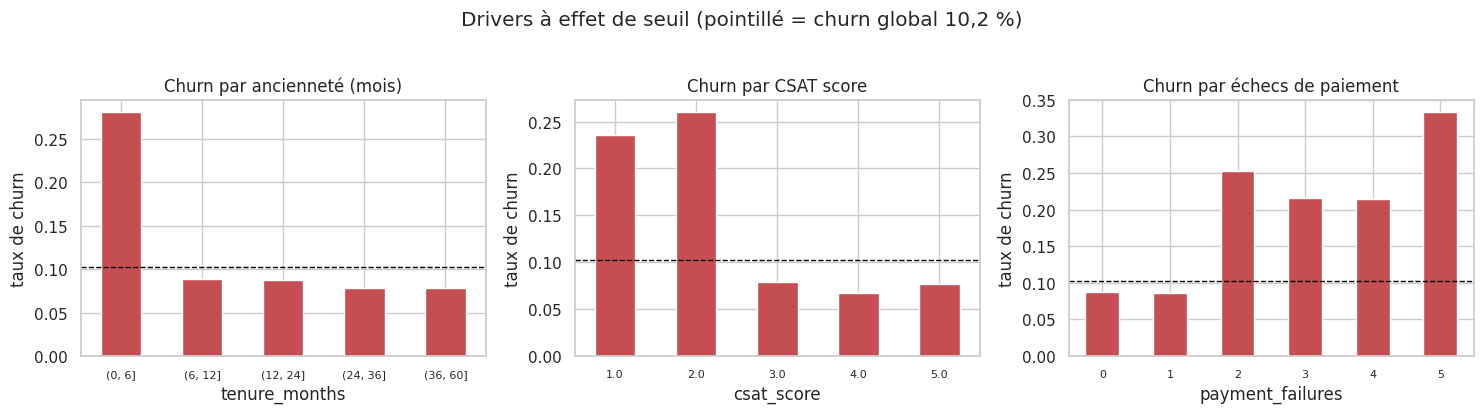

tenure : {'(0, 6]': 0.281, '(6, 12]': 0.088, '(12, 24]': 0.088, '(24, 36]': 0.079, '(36, 60]': 0.078}
csat   : {1.0: 0.235, 2.0: 0.26, 3.0: 0.079, 4.0: 0.067, 5.0: 0.077}
payfail: {0: 0.088, 1: 0.087, 2: 0.253, 3: 0.215, 4: 0.214, 5: 0.333}


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
tb = pd.cut(df["tenure_months"], [0, 6, 12, 24, 36, 60])
g1 = df.groupby(tb, observed=True)[config.TARGET].mean(); g1.index = g1.index.astype(str)
g1.plot(kind="bar", ax=axes[0], color="#C44E52"); axes[0].set_title("Churn par ancienneté (mois)")
g2 = df.groupby("csat_score")[config.TARGET].mean()
g2.plot(kind="bar", ax=axes[1], color="#C44E52"); axes[1].set_title("Churn par CSAT score")
g3 = df.groupby("payment_failures")[config.TARGET].mean()
g3.plot(kind="bar", ax=axes[2], color="#C44E52"); axes[2].set_title("Churn par échecs de paiement")
for ax in axes:
    ax.axhline(rate, color="black", ls="--", lw=1); ax.set_ylabel("taux de churn")
    ax.tick_params(axis="x", rotation=0, labelsize=8)
fig.suptitle("Drivers à effet de seuil (pointillé = churn global 10,2 %)", y=1.03)
fig.tight_layout(); fig.savefig(FIG/"07_nonlinear_drivers.png", dpi=120); plt.show()

print("tenure :", g1.round(3).to_dict())
print("csat   :", g2.round(3).to_dict())
print("payfail:", g3.round(3).to_dict())

## 7. Variables catégorielles vs churn

Les variables purement catégoriques (pays, ville, segment, canal...) ont un pouvoir
discriminant **faible** : tous les taux restent proches du taux global (~9–11,5 %). Le signal
est concentré dans les variables comportementales/contractuelles vues ci-dessus.

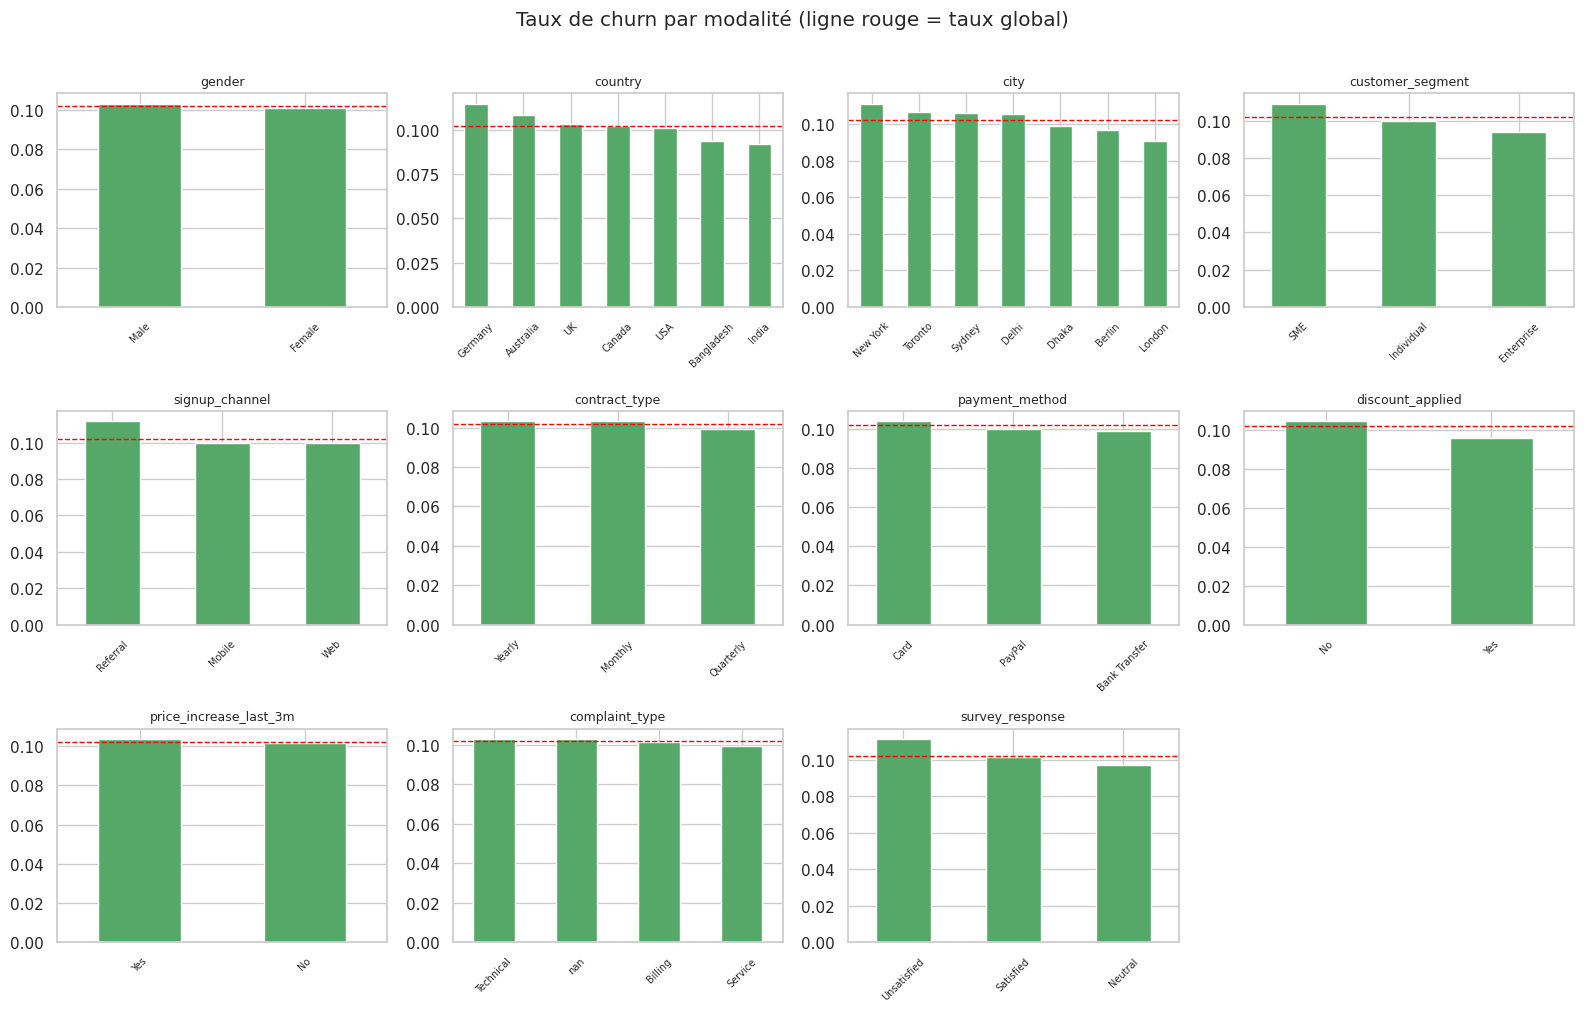

In [11]:
cat = config.CATEGORICAL_FEATURES
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, col in zip(axes.ravel(), cat):
    grp = df.groupby(col, dropna=False)[config.TARGET].mean().sort_values(ascending=False)
    grp.plot(kind="bar", ax=ax, color="#55A868")
    ax.axhline(rate, color="red", ls="--", lw=1)
    ax.set_title(col, fontsize=9); ax.set_xlabel("")
    ax.tick_params(labelsize=7, axis="x", rotation=45)
for ax in axes.ravel()[len(cat):]:
    ax.axis("off")
fig.suptitle("Taux de churn par modalité (ligne rouge = taux global)", y=1.01)
fig.tight_layout(); fig.savefig(FIG/"05_churn_rate_by_category.png", dpi=120); plt.show()

## 8. Variables clés selon le churn (boxplots)

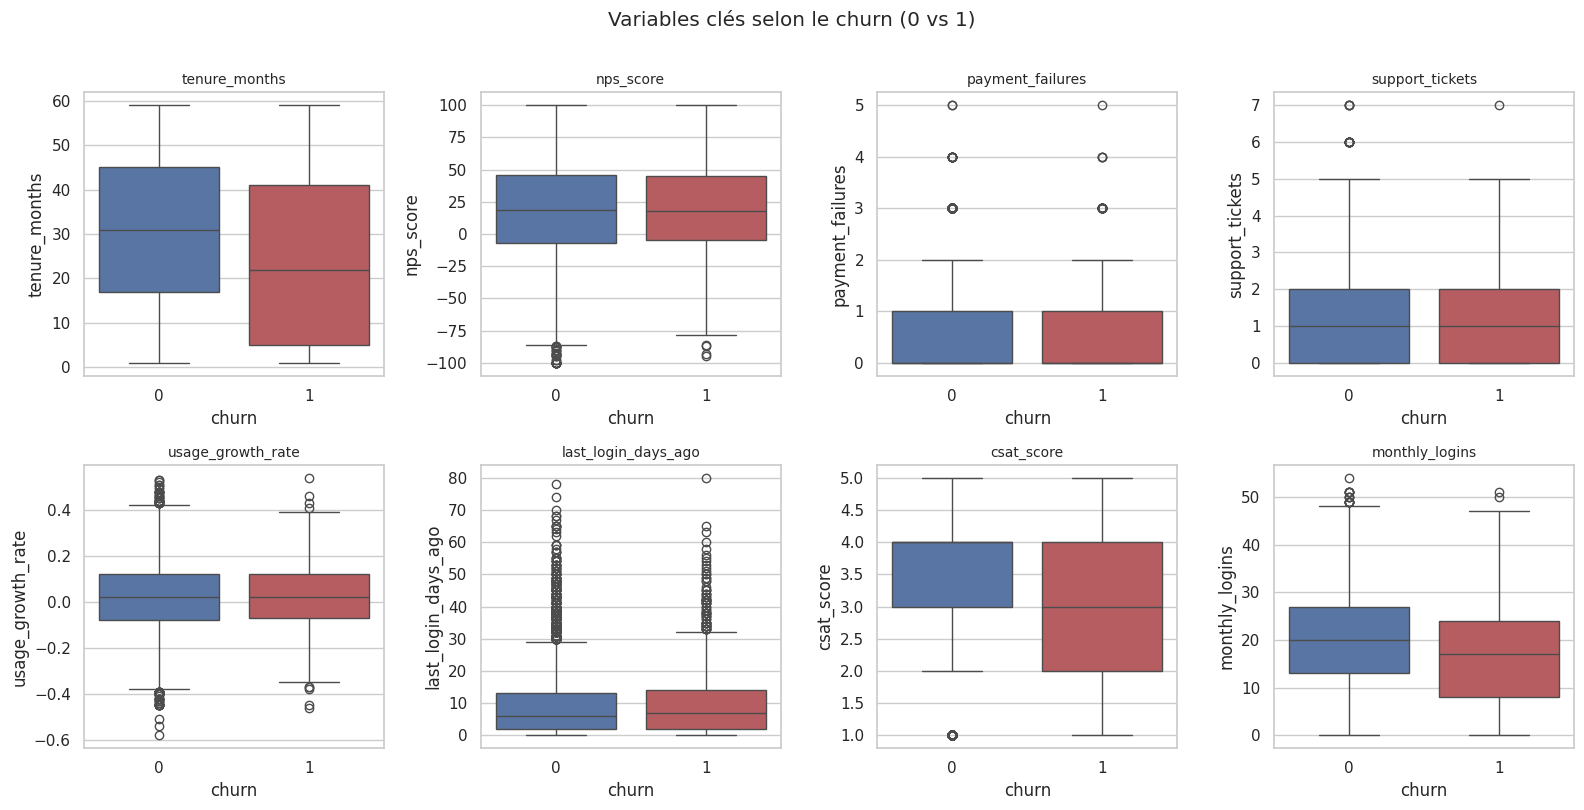

In [12]:
key_num = ["tenure_months","nps_score","payment_failures","support_tickets",
           "usage_growth_rate","last_login_days_ago","csat_score","monthly_logins"]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.ravel(), key_num):
    sns.boxplot(data=df, x=config.TARGET, y=col, hue=config.TARGET, legend=False,
                ax=ax, palette=["#4C72B0", "#C44E52"])
    ax.set_title(col, fontsize=10); ax.set_xlabel("churn")
fig.suptitle("Variables clés selon le churn (0 vs 1)", y=1.01)
fig.tight_layout(); fig.savefig(FIG/"06_keyvars_by_churn.png", dpi=120); plt.show()

## 9. Multicolinéarité

In [13]:
cmat = df[num].corr().abs()
upper = cmat.where(np.triu(np.ones(cmat.shape), k=1).astype(bool))
pairs = upper.stack().sort_values(ascending=False)
high = pairs[pairs > 0.7]
print(f"Paires |corr| > 0.7 : {len(high)}")
display(high.to_frame("abs_corr").round(3))

Paires |corr| > 0.7 : 1


,,abs_corr
monthly_fee,total_revenue,0.709


## 10. Synthèse de l'EDA

| Constat | Implication pour la modélisation |
|---|---|
| Churn déséquilibré (**10,2 %**) | Métriques : **Recall / F1 / PR-AUC** ; `class_weight` / `scale_pos_weight` ; ajustement du seuil |
| Manquants sur `complaint_type` (~20 %) | Imputation `"None"` (= pas de plainte) dans le pipeline |
| Corrélations linéaires faibles, mais **drivers à effet de seuil** (tenure, CSAT, payment_failures) | Avantage attendu aux modèles **non-linéaires** (RF, XGBoost, MLP) vs LogReg |
| Catégorielles peu discriminantes | OneHot conservé, mais signal porté par les variables comportementales |
| `monthly_fee ~ total_revenue` (0.71) | Multicolinéarité à garder en tête pour l'interprétation (pas de suppression auto) |
| `customer_id` identifiant | À exclure des features |